In [5]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

In [6]:
# Load Data
df = pd.read_csv("GlobalWeatherRepository.csv")
df.head()

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,...,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,...,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


In [7]:
# Preprocessing 

# Convert 'last_updated' column to datetime format for time series analysis
df['last_updated'] = pd.to_datetime(df['last_updated'])

# Sort dataset chronologically
df = df.sort_values('last_updated')

# Select the city with the most observations (avoid empty dataset issue)
city = df['location_name'].value_counts().index[0]
print("Using city:", city)

# Filter dataset for that city
df = df[df['location_name'] == city].copy()

# Drop irrelevant or non-numeric columns that are not useful for modeling
drop_cols = [
    'country', 'location_name', 'timezone',
    'condition_text', 'wind_direction',
    'sunrise', 'sunset', 'moonrise', 'moonset',
    'moon_phase'
]
df = df.drop(columns=drop_cols, errors='ignore')

# Remove rows with missing values
df = df.dropna()

Using city: Amman


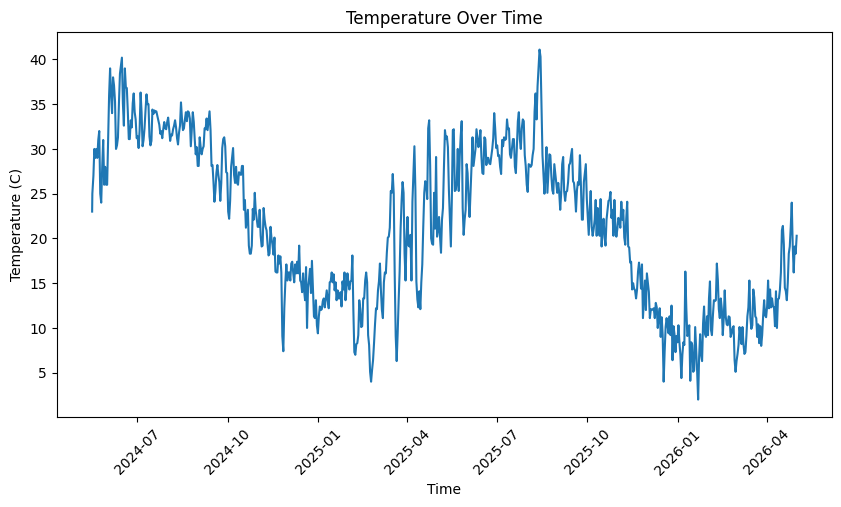

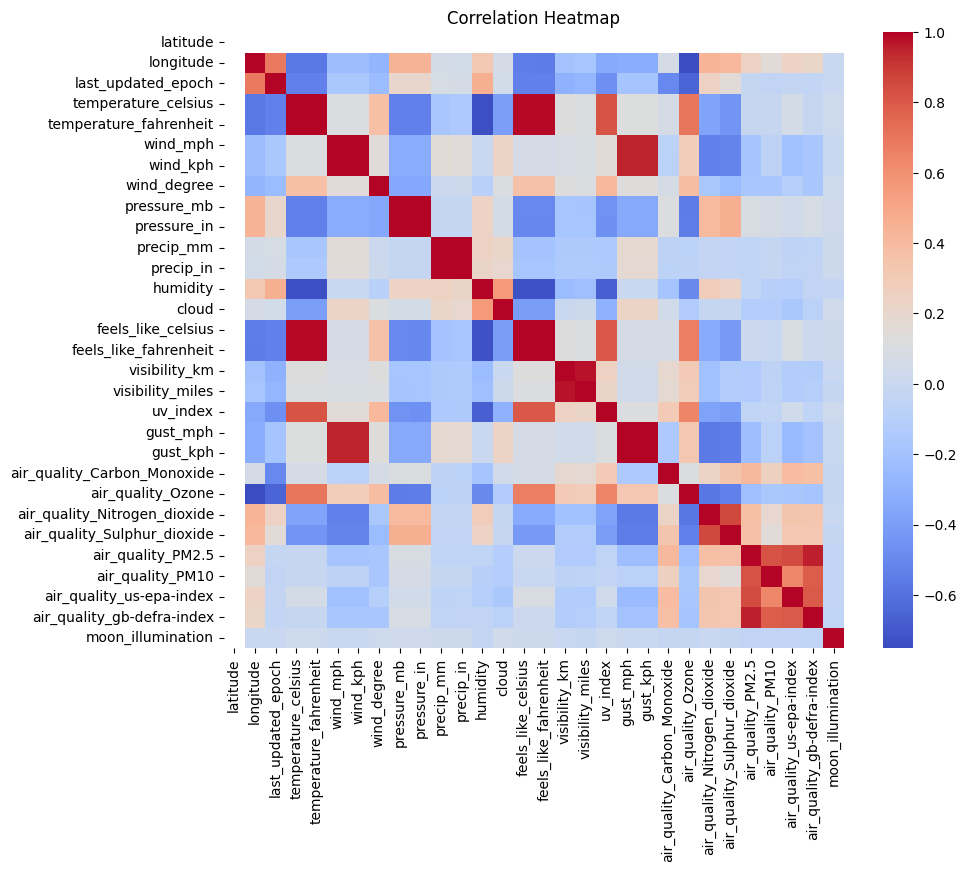

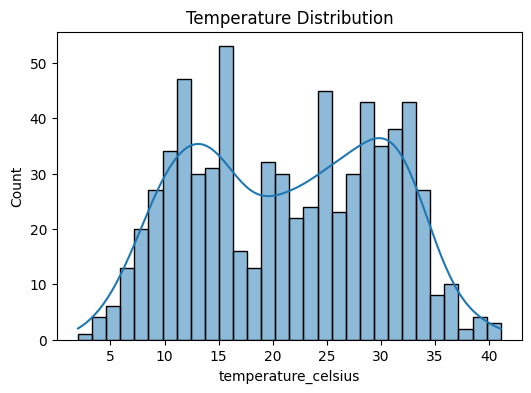

In [13]:
# EDA: Visualization

#  Temperature over time (for one city later)
plt.figure(figsize=(10,5))
plt.plot(df['last_updated'], df['temperature_celsius'])
plt.title("Temperature Over Time")
plt.xlabel("Time")
plt.ylabel("Temperature (C)")
plt.xticks(rotation=45)
plt.show()

# Correlation heatmap (numeric only)
plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include='number').corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Distribution of temperature
plt.figure(figsize=(6,4))
sns.histplot(df['temperature_celsius'], bins=30, kde=True)
plt.title("Temperature Distribution")
plt.show()

In [104]:
# Feature Engineering

# Create prediction target: temperature of the next time step (t+1)
df['temp_tomorrow'] = df['temperature_celsius'].shift(-1)

# Drop last row with NaN target
df = df.dropna()

# Extract time-based features to capture temporal patterns
df['hour'] = df['last_updated'].dt.hour
df['day'] = df['last_updated'].dt.day
df['month'] = df['last_updated'].dt.month

# Select relevant features for modeling
features = [
    'temperature_celsius',   # autoregressive component
    'humidity',
    'pressure_mb',
    'wind_kph',
    'precip_mm',
    'cloud',
    'uv_index',
    'visibility_km',
    'hour',
    'day',
    'month'
]


In [108]:
# Train/Test Split (Time Series)

# Use chronological split instead of random split to preserve time dependency
split = int(len(df) * 0.8)


# Define feature matrix (X) and target variable (y)
X = df[features]
y = df['temp_tomorrow']

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (570, 11)
Test shape: (143, 11)


In [143]:
# Model Training

# Time-series cross-validation (avoid data leakage)
tscv = TimeSeriesSplit(n_splits=5)

# Linear Regression (baseline model)
lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [125]:
# Ridge Regression (tuning alpha)
# -------------------------
# Regularization strength controls model complexity
ridge_params = {
    'alpha': np.logspace(-4, 3, 200) 
}

ridge_grid = GridSearchCV(
    Ridge(),
    ridge_params,
    cv=tscv,
    scoring='neg_mean_squared_error'
)

ridge_grid.fit(X_train, y_train)

# Best tuned Ridge model
best_ridge = ridge_grid.best_estimator_

print("Best Ridge params:", ridge_grid.best_params_)


Best Ridge params: {'alpha': np.float64(1.8041864093920719)}


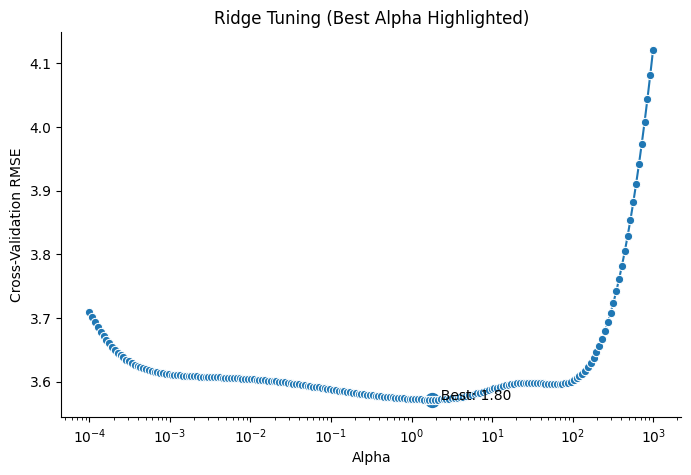

In [131]:
best_alpha = ridge_grid.best_params_['alpha']
best_rmse = ridge_results.loc[
    ridge_results['param_alpha'] == best_alpha, 'rmse'
].values[0]

plt.figure(figsize=(8,5))
sns.lineplot(
    data=ridge_results,
    x='param_alpha',
    y='rmse',
    marker='o'
)

# highlight best point
plt.scatter(best_alpha, best_rmse, s=100)
plt.text(best_alpha, best_rmse, f'  Best: {best_alpha:.2f}')

plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Cross-Validation RMSE')
plt.title('Ridge Tuning (Best Alpha Highlighted)')

sns.despine()
plt.show()

In [135]:
# Random Forest (tuning multiple parameters)
# -------------------------
# Random Forest captures nonlinear relationships
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 8, 12, None],
    'max_features': [0.4, 0.6, 0.8, 1.0],
    'min_samples_leaf': [1, 2, 3, 5, 10],
    'min_samples_split': [2, 5, 10]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_params,
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

# Best tuned Random Forest model
best_rf = rf_grid.best_estimator_

print("Best Random Forest params:", rf_grid.best_params_)

Best Random Forest params: {'max_depth': 5, 'max_features': 0.8, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 300}


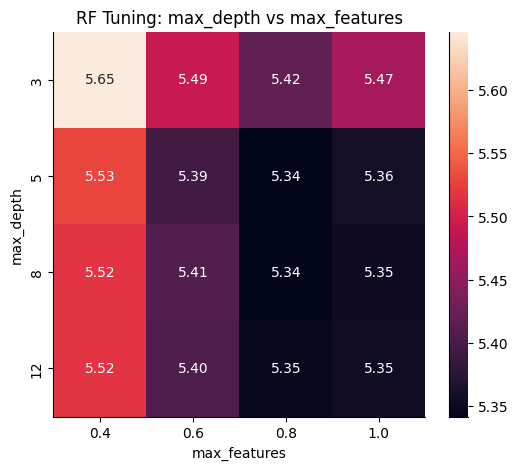

In [139]:
# Convert results to DataFrame
rf_results = pd.DataFrame(rf_grid.cv_results_)

# Convert score
rf_results['rmse'] = np.sqrt(-rf_results['mean_test_score'])

# Pivot table
pivot = rf_results.pivot_table(
    values='rmse',
    index='param_max_depth',
    columns='param_max_features'
)

# Plot heatmap
plt.figure(figsize=(6,5))
sns.heatmap(pivot, annot=True, fmt=".2f")

plt.title('RF Tuning: max_depth vs max_features')
plt.xlabel('max_features')
plt.ylabel('max_depth')

sns.despine()
plt.show()

In [145]:
def rmse(model):
    pred = model.predict(X_test)
    return np.sqrt(mean_squared_error(y_test, pred))

print("Linear Regression RMSE:", rmse(lr))
print("Ridge RMSE:", rmse(best_ridge))
print("Random Forest RMSE:", rmse(best_rf))

Linear Regression RMSE: 2.8076314322665916
Ridge RMSE: 2.709061100614453
Random Forest RMSE: 2.8209879424290776
